In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

## Step 1 — Load & Audit

In [73]:
df_raw = pd.read_csv("dataset.csv")
print(df_raw.shape)

(14096, 95)


In [74]:
df_raw.dtypes

game_year               int64
game_date                 str
player_name               str
pitcher                 int64
batter                  int64
                       ...   
spin_axis             float64
delta_home_win_exp    float64
delta_run_exp         float64
bat_speed             float64
swing_length          float64
Length: 95, dtype: object

In [75]:
df_raw.duplicated().sum()

0

In [76]:
df_raw.head()

,game_year,game_date,player_name,pitcher,batter,balls,strikes,inning,inning_topbot,at_bat_number,...,post_home_score,post_bat_score,post_fld_score,if_fielding_alignment,of_fielding_alignment,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length
0,2025,2025-09-30,"Ashcraft, Graham",668933,605141,0,0,8,Bot,73,...,10,10,5,Standard,Standard,42.0,0.0,0.041,NaN,NaN
1,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,0,8,Bot,73,...,10,10,5,Standard,Standard,201.0,0.0,-0.050,NaN,NaN
2,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,1,8,Bot,73,...,10,10,5,Standard,Standard,23.0,0.0,-0.061,65.0,6.0
3,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,2,8,Bot,73,...,10,10,5,Standard,Standard,39.0,0.0,0.000,53.1,7.2
4,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,2,8,Bot,73,...,10,10,5,Standard,Standard,201.0,0.0,0.043,NaN,NaN


In [77]:
df_raw.describe()

,game_year,pitcher,batter,balls,strikes,inning,at_bat_number,pitch_number,release_speed,release_pos_x,...,fld_score,post_away_score,post_home_score,post_bat_score,post_fld_score,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length
count,14096.0,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,...,14096.000000,14096.00000,14096.000000,14096.000000,14096.000000,14089.000000,14096.000000,14096.000000,6704.000000,6704.000000
mean,2025.0,654432.648127,646575.503689,0.872375,0.916359,5.273624,40.607406,2.925227,90.682740,-0.796971,...,2.110031,1.94431,2.223184,2.057463,2.110031,176.305203,0.000167,-0.002535,69.569391,7.244824
std,0.0,60782.502545,49297.380592,0.968588,0.829502,3.027925,25.720786,1.741043,6.008374,1.893833,...,2.523059,2.20987,2.625899,2.334641,2.523059,74.953615,0.027601,0.222230,9.545128,1.054472
min,2025.0,453286.000000,457759.000000,0.000000,0.000000,1.000000,1.000000,1.000000,69.200000,-4.330000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,-0.509000,-0.530000,2.000000,0.500000
25%,2025.0,608718.000000,608701.000000,0.000000,0.000000,3.000000,20.000000,1.000000,86.200000,-2.160000,...,0.000000,0.00000,0.000000,0.000000,0.000000,132.000000,0.000000,-0.063000,67.100000,6.600000
50%,2025.0,666200.000000,664023.000000,1.000000,1.000000,5.000000,39.000000,3.000000,91.600000,-1.600000,...,1.000000,1.00000,1.000000,1.000000,1.000000,201.000000,0.000000,-0.039000,71.200000,7.300000
75%,2025.0,682120.000000,676391.000000,1.000000,2.000000,7.000000,59.000000,4.000000,95.700000,1.040000,...,3.000000,3.00000,3.000000,3.000000,3.000000,222.000000,0.000000,0.039000,74.600000,8.000000
max,2025.0,813349.000000,807799.000000,3.000000,2.000000,18.000000,153.000000,13.000000,104.500000,4.100000,...,13.000000,13.00000,13.000000,13.000000,13.000000,360.000000,0.412000,2.696000,87.600000,10.400000


## Step 2 — Filter to Blue Jays Pitching

In [78]:
# game_type == 'R' filter skipped — dataset is postseason only ('P')
df_raw["game_type"].unique()

<StringArray>
['F', 'D', 'L', 'W']
Length: 4, dtype: str

In [79]:
tor_games = df_raw[(df_raw["home_team"] == "TOR") | (df_raw["away_team"] == "TOR")]

df = tor_games[
    ((tor_games["home_team"] == "TOR") & (tor_games["inning_topbot"] == "Top"))
    | ((tor_games["away_team"] == "TOR") & (tor_games["inning_topbot"] == "Bot"))
].copy().reset_index(drop=True)

print(f"Rows: {len(df):,} | Pitchers: {df['pitcher'].nunique()} | Games: {df['game_pk'].nunique()}")

Rows: 2,788 | Pitchers: 15 | Games: 18


## Step 3 — Drop Deprecated & Empty Columns

In [80]:
fully_empty = df.columns[df.isnull().all()].tolist()
duplicate_cols = [c for c in df.columns if c.endswith(".1") or c.endswith(".2")]

df.drop(columns=fully_empty + duplicate_cols, inplace=True)
print(f"Dropped {len(fully_empty + duplicate_cols)} columns | Remaining: {df.shape[1]}")

Dropped 10 columns | Remaining: 85


## Step 4 — Missing Values

In [81]:
missing = pd.DataFrame({
    "count": df.isnull().sum(),
    "pct":   (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values("pct", ascending=False)

missing[missing["count"] > 0]

,count,pct
on_3b,2599,93.22
estimated_ba_using_speedangle,2340,83.93
launch_speed_angle,2340,83.93
hc_y,2337,83.82
hc_x,2337,83.82
bb_type,2337,83.82
on_2b,2315,83.03
hit_location,2188,78.48
estimated_woba_using_speedangle,2092,75.04
woba_denom,2090,74.96


In [82]:
# Null = base empty, not missing data
df[["on_1b", "on_2b", "on_3b"]] = df[["on_1b", "on_2b", "on_3b"]].fillna(0)

In [83]:
core_cols = ["release_speed", "release_spin_rate", "plate_x", "plate_z", "effective_speed"]
before = len(df)
df.dropna(subset=core_cols, inplace=True)
print(f"Dropped {before - len(df)} rows with missing core mechanics")

Dropped 0 rows with missing core mechanics


## Step 5 — Fix Data Types

In [84]:
df["game_date"] = pd.to_datetime(df["game_date"], format="%Y-%m-%d")

cat_cols = [
    "pitch_name", "pitch_type", "stand", "p_throws", "inning_topbot",
    "description", "events", "bb_type", "if_fielding_alignment",
    "of_fielding_alignment", "type", "game_type"
]
for col in [c for c in cat_cols if c in df.columns]:
    df[col] = df[col].astype("category")

print(df[["game_date"] + [c for c in cat_cols if c in df.columns]].dtypes)

game_date                datetime64[us]
pitch_name                     category
pitch_type                     category
stand                          category
p_throws                       category
inning_topbot                  category
description                    category
events                         category
bb_type                        category
if_fielding_alignment          category
of_fielding_alignment          category
type                           category
game_type                      category
dtype: object


## Step 6 — Remove Outliers (IQR per Pitch Type)

In [85]:
print("spin_rate == 0:", (df["release_spin_rate"] == 0).sum())
if "release_extension" in df.columns:
    print("negative extension:", (df["release_extension"] < 0).sum())
if "launch_speed" in df.columns:
    print("launch_speed > 115:", (df["launch_speed"] > 115).sum())

spin_rate == 0: 0
negative extension: 0
launch_speed > 115: 3


In [86]:
mechanics_cols = ["release_speed", "release_spin_rate", "effective_speed"]
if "release_extension" in df.columns:
    mechanics_cols.append("release_extension")

def iqr_mask(group, col):
    Q1, Q3 = group[col].quantile(0.25), group[col].quantile(0.75)
    IQR = Q3 - Q1
    return (group[col] >= Q1 - 1.5 * IQR) & (group[col] <= Q3 + 1.5 * IQR)

before = len(df)
keep = pd.Series(True, index=df.index)

for col in mechanics_cols:
    mask = (
        df.groupby("pitch_name", observed=True)
        .apply(lambda g: iqr_mask(g, col))
        .reset_index(level=0, drop=True)
        .reindex(df.index)
    )
    keep &= mask

df = df[keep].copy().reset_index(drop=True)
print(f"Removed {before - len(df)} outlier rows | Remaining: {len(df):,}")

Removed 166 outlier rows | Remaining: 2,622


## Step 7 — Engineer Shared Features

In [87]:
# Cumulative pitch count per pitcher per game (Q1, Q2)
df["cum_pitch_count"] = df.groupby(["game_pk", "pitcher"]).cumcount() + 1

# Game phase: Early 1-3 / Mid 4-6 / Late 7+ (Q1)
df["game_phase"] = pd.cut(
    df["inning"],
    bins=[0, 3, 6, float("inf")],
    labels=["Early", "Mid", "Late"]
)

# Score differential from pitcher's perspective (Q2, Q3)
df["score_diff"] = df["bat_score"] - df["fld_score"]

print(df[["cum_pitch_count", "game_phase", "score_diff"]].describe())

       cum_pitch_count   score_diff
count      2622.000000  2622.000000
mean         26.181541    -1.199466
std          24.228103     3.261857
min           1.000000   -12.000000
25%           7.000000    -2.000000
50%          16.000000     0.000000
75%          43.000000     0.000000
max         104.000000     7.000000


## Step 8 — General EDA Visualizations

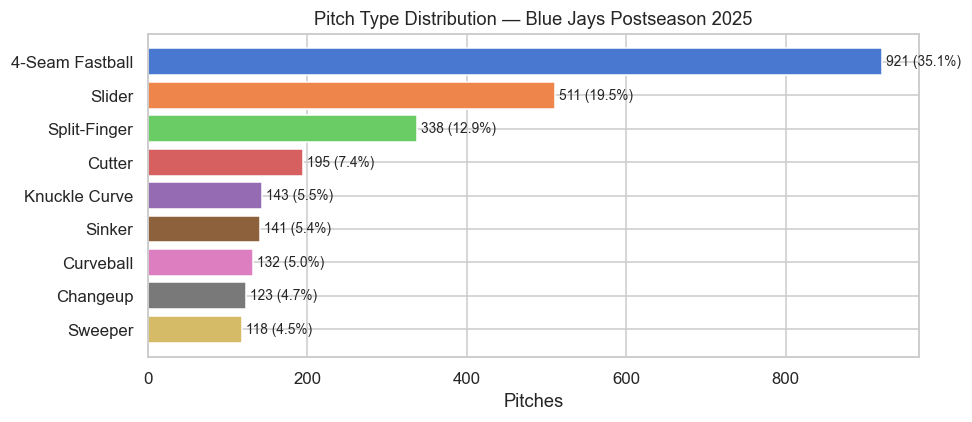

In [88]:
pitch_counts = df["pitch_name"].value_counts()
total = pitch_counts.sum()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(pitch_counts.index, pitch_counts.values,
               color=sns.color_palette("muted", len(pitch_counts)))
for bar, n in zip(bars, pitch_counts.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f"{n} ({n/total*100:.1f}%)", va="center", fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Pitches")
ax.set_title("Pitch Type Distribution — Blue Jays Postseason 2025")
plt.tight_layout()
plt.show()

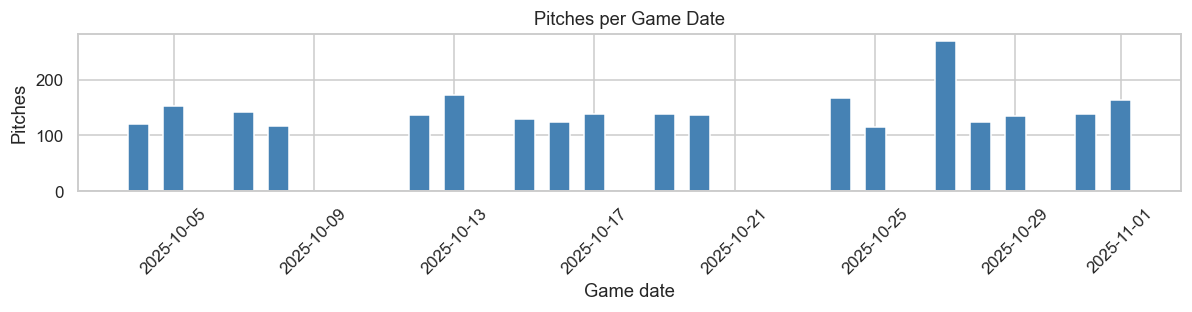

In [89]:
pitches_per_date = df.groupby("game_date").size()

fig, ax = plt.subplots(figsize=(11, 3))
ax.bar(pitches_per_date.index, pitches_per_date.values, width=0.6, color="steelblue")
ax.set_xlabel("Game date")
ax.set_ylabel("Pitches")
ax.set_title("Pitches per Game Date")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

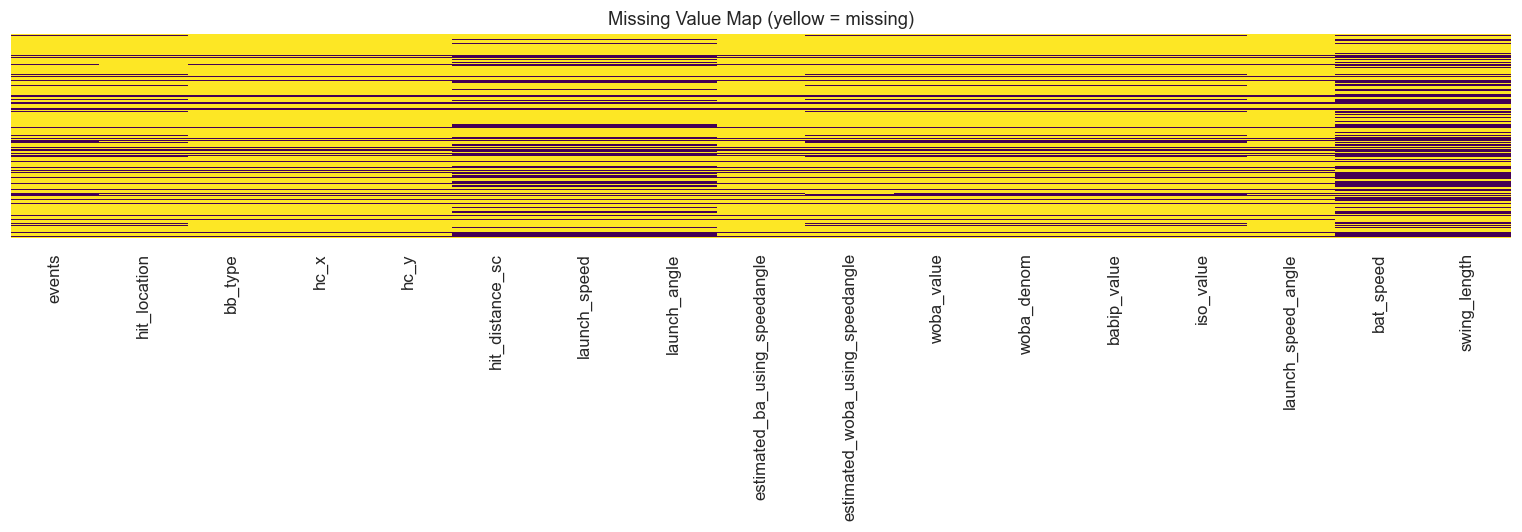

In [90]:
cols_with_missing = df.columns[df.isnull().any()].tolist()
sample = df.sample(min(500, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(sample[cols_with_missing].isnull(), cbar=False,
            yticklabels=False, cmap="viridis", ax=ax)
ax.set_title("Missing Value Map (yellow = missing)")
plt.tight_layout()
plt.show()

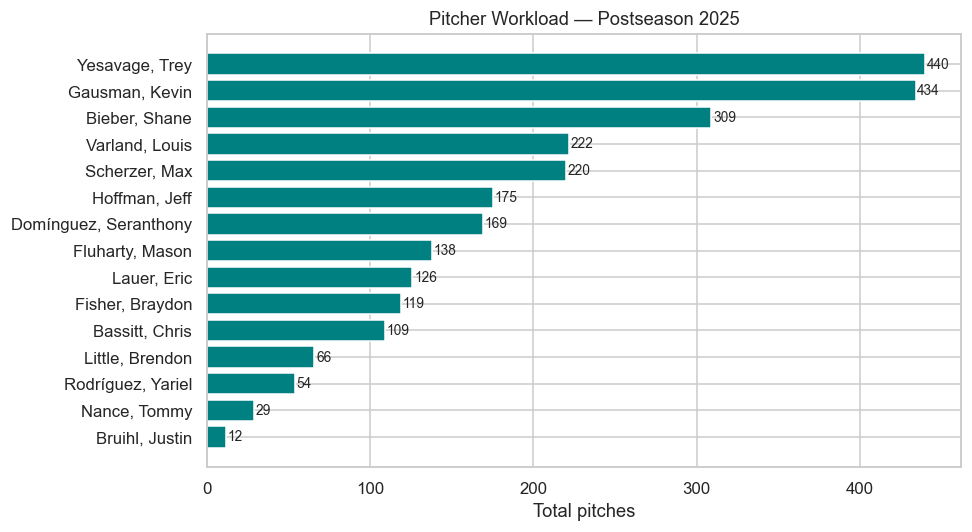

In [91]:
workload = df.groupby("player_name", observed=True).size().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(workload.index, workload.values, color="teal")
for bar, val in zip(bars, workload.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=9)
ax.set_xlabel("Total pitches")
ax.set_title("Pitcher Workload — Postseason 2025")
plt.tight_layout()
plt.show()

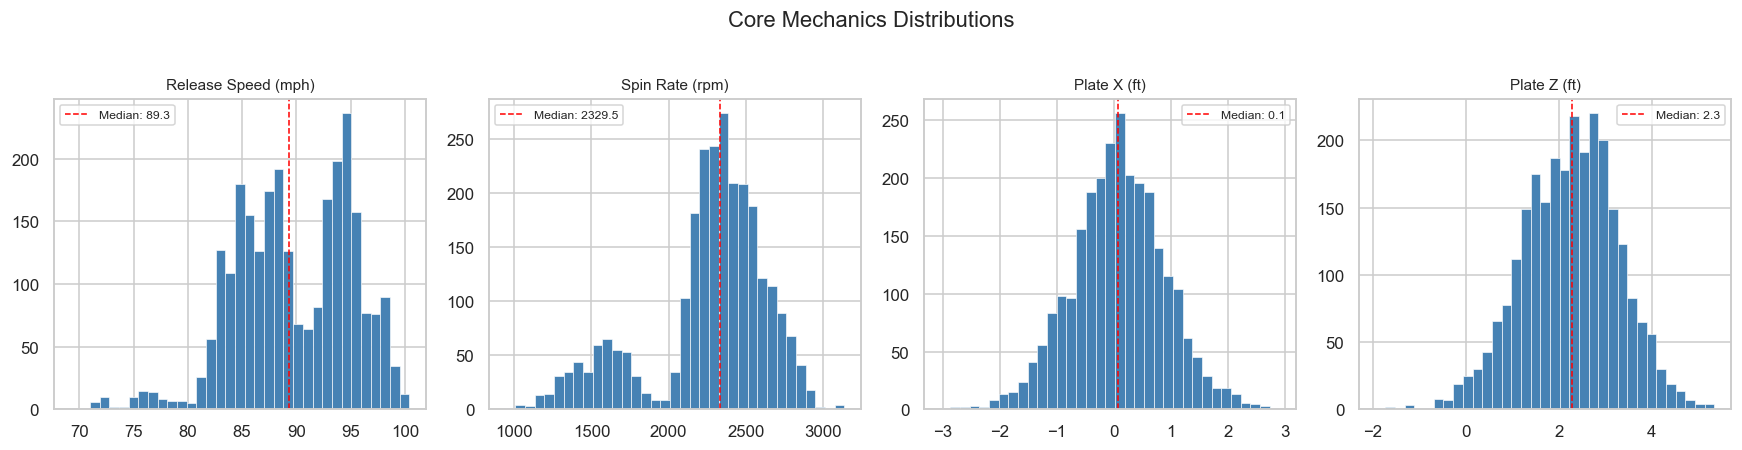

In [92]:
core_mechanics = [
    ("release_speed",     "Release Speed (mph)"),
    ("release_spin_rate", "Spin Rate (rpm)"),
    ("plate_x",           "Plate X (ft)"),
    ("plate_z",           "Plate Z (ft)"),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (col, label) in zip(axes, core_mechanics):
    ax.hist(df[col].dropna(), bins=35, color="steelblue", edgecolor="white", linewidth=0.4)
    ax.axvline(df[col].median(), color="red", linestyle="--", linewidth=1,
               label=f"Median: {df[col].median():.1f}")
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)
plt.suptitle("Core Mechanics Distributions", y=1.02)
plt.tight_layout()
plt.show()

## Verification

In [93]:
print(f"Shape: {df.shape}")
print(f"Pitchers: {df['player_name'].nunique()} | Games: {df['game_pk'].nunique()}")
print()
print("Core mechanic nulls:")
print(df[["release_speed", "release_spin_rate", "plate_x", "plate_z", "effective_speed"]].isnull().sum())
print()
for feat in ["cum_pitch_count", "game_phase", "score_diff"]:
    print(f"{feat}: {'OK' if feat in df.columns else 'MISSING'}")
print()
bad = [c for c in df.columns if "deprecated" in c or c.endswith(".1") or c.endswith(".2")]
print(f"Bad columns: {bad or 'None'}")

Shape: (2622, 88)
Pitchers: 15 | Games: 18

Core mechanic nulls:
release_speed        0
release_spin_rate    0
plate_x              0
plate_z              0
effective_speed      0
dtype: int64

cum_pitch_count: OK
game_phase: OK
score_diff: OK

Bad columns: None


In [94]:
df.to_pickle("dataset_cleaned.pkl")
print(f"Saved → dataset_cleaned.pkl ({df.shape[0]:,} rows × {df.shape[1]} cols)")

Saved → dataset_cleaned.pkl (2,622 rows × 88 cols)
